# Análisis exploratorio complementario - Jeferson David Vargas Toca

Microproyecto DiabetesRisk

1. Calidad de datos (duplicados, valores inválidos).
2. Outliers en variables continuas.
3. Riesgo relativo por variable categórica.
4. Relación entre BMI, edad y diabetes.
5. Un **índice acumulado de factores de riesgo**, combinando las variables que se piensan usar en el formulario del tablero, para ver cómo escala la prevalencia de diabetes a medida que una persona acumula más factores.

## 0. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

TARGET = "Diabetes_binary"

## 1. Lectura de los datos

In [2]:
ruta_csv = "../data/diabetes_binary_health_indicators_BRFSS2015.csv"
df = pd.read_csv(ruta_csv)
df.shape

(253680, 22)

## 2. Calidad de datos

Antes de mirar distribuciones, revisamos si hay problemas que puedan afectar el modelado: nulos, duplicados exactos y valores fisiológicamente imposibles.

In [3]:
print(df.isna().sum().sum(), "valores nulos")

duplicados = df.duplicated().sum()
print(duplicados, "filas duplicadas exactas "
      f"({duplicados / len(df):.1%} del total)")

bmi_invalido = (df["BMI"] <= 0).sum()
print(bmi_invalido, "registros con BMI <= 0 (posible dato inválido)")

0 valores nulos
24206 filas duplicadas exactas (9.5% del total)
0 registros con BMI <= 0 (posible dato inválido)


**Hallazgo:** el dataset no tiene nulos ni BMI inválido, pero sí un **9.5% de filas duplicadas exactas**. Esto no se menciona en el resto del análisis del equipo. No sabemos si son respuestas legítimamente repetidas en la encuesta BRFSS o artefactos de la construcción del dataset público; hay que decidir si se deduplican antes de entrenar el modelo, para no inflar artificialmente el tamaño de muestra.

### 2.1 ¿Los duplicados son aleatorios o se concentran en un perfil típico?

El 9.5% de filas duplicadas podría ser ruido (error de captura) o podría reflejar que, al tener variables muy discretizadas (binarias/categóricas), es esperable que personas distintas respondan exactamente igual. Comparamos la prevalencia de diabetes entre filas duplicadas y únicas, y miramos qué tan repetido está el perfil más común.

35575 filas participan en algun grupo duplicado (14.0%)
Prevalencia de diabetes en filas duplicadas: 1.3%
Prevalencia de diabetes en filas unicas:      16.0%
11369 perfiles distintos se repiten; el mas repetido aparece 59 veces
Perfil mas repetido: {'Diabetes_binary': np.float64(0.0), 'HighBP': np.float64(0.0), 'HighChol': np.float64(0.0), 'BMI': np.float64(21.0), 'Smoker': np.float64(0.0), 'GenHlth': np.float64(1.0), 'Age': np.float64(6.0), 'Income': np.float64(8.0)}


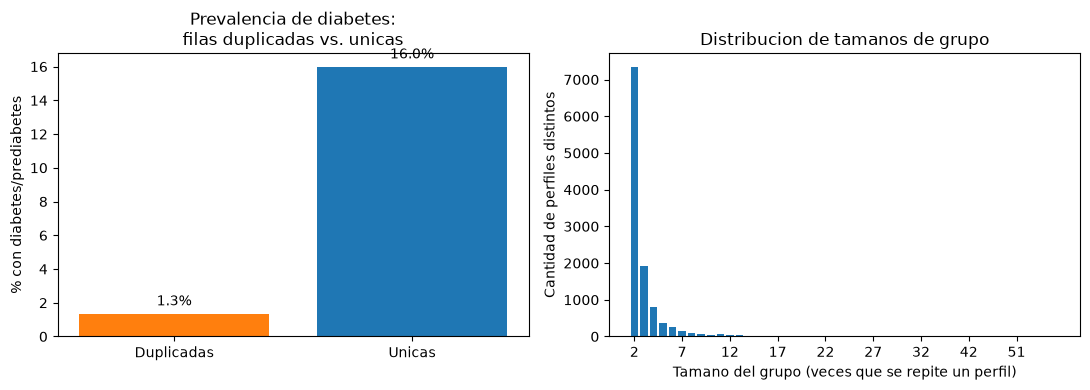

In [4]:
mask_duplicados = df.duplicated(keep=False)
print(f"{mask_duplicados.sum()} filas participan en algun grupo duplicado ({mask_duplicados.sum()/len(df):.1%})")

tasa_dup = df.loc[mask_duplicados, TARGET].mean()
tasa_unicos = df.loc[~mask_duplicados, TARGET].mean()
print(f"Prevalencia de diabetes en filas duplicadas: {tasa_dup:.1%}")
print(f"Prevalencia de diabetes en filas unicas:      {tasa_unicos:.1%}")

grupos = df[mask_duplicados].groupby(list(df.columns)).size().sort_values(ascending=False)
print(f"{len(grupos)} perfiles distintos se repiten; el mas repetido aparece {grupos.iloc[0]} veces")

top1 = dict(zip(df.columns, grupos.index[0]))
print("Perfil mas repetido:", {k: v for k, v in top1.items() if k in [
    'Diabetes_binary', 'HighBP', 'HighChol', 'BMI', 'GenHlth', 'Age', 'Income', 'Smoker']})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.bar(["Duplicadas", "Unicas"], [tasa_dup * 100, tasa_unicos * 100], color=["tab:orange", "tab:blue"])
ax1.set_ylabel("% con diabetes/prediabetes")
ax1.set_title("Prevalencia de diabetes:\nfilas duplicadas vs. unicas")
for i, v in enumerate([tasa_dup, tasa_unicos]):
    ax1.text(i, v * 100 + 0.5, f"{v:.1%}", ha="center")

tam_grupos = grupos.value_counts().sort_index()
ax2.bar(tam_grupos.index.astype(str), tam_grupos.values)
ax2.set_xlabel("Tamano del grupo (veces que se repite un perfil)")
ax2.set_ylabel("Cantidad de perfiles distintos")
ax2.set_title("Distribucion de tamanos de grupo")
ax2.set_xticks(ax2.get_xticks()[::5])

fig.tight_layout()
plt.show()

**Hallazgo:** los duplicados NO son aleatorios: la prevalencia de diabetes entre filas duplicadas es **1.3%**, muy por debajo del **16.0%** en filas únicas. El perfil que más se repite (59 veces) es alguien de edad media, sin presión ni colesterol altos, activo físicamente, con buena salud general y sin diabetes — es decir, el "perfil sano típico". Esto tiene sentido: con variables tan discretizadas, es esperable que muchas personas sanas respondan exactamente igual a las 21 preguntas, mientras que los perfiles con enfermedad tienden a ser más heterogéneos (más variables continuas como `BMI`, `MentHlth`, `PhysHlth` con valores distintos).

**Implicación práctica:** eliminar los duplicados sin criterio sesgaría el dataset, quitando desproporcionadamente casos sanos y **inflando artificialmente la prevalencia de diabetes** — hay que tratarlos como observaciones legítimas, no como error de captura.

## 3. Outliers en variables continuas

Usamos la regla del rango intercuartílico (IQR) sobre las tres variables continuas del dataset: `BMI`, `MentHlth` y `PhysHlth`.

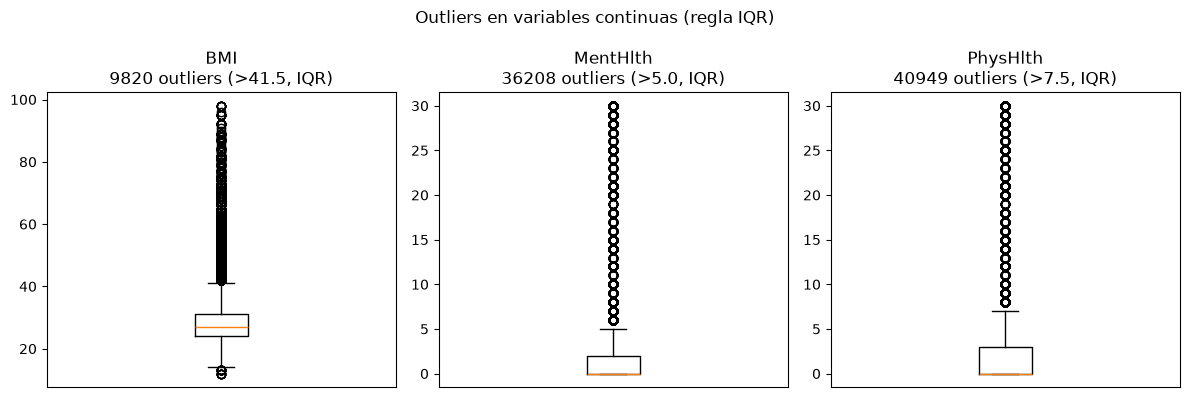

In [5]:
continuas = ["BMI", "MentHlth", "PhysHlth"]

fig, axes = plt.subplots(1, len(continuas), figsize=(4 * len(continuas), 4))
for ax, var in zip(axes, continuas):
    ax.boxplot(df[var], orientation="vertical")
    q1, q3 = df[var].quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_sup = q3 + 1.5 * iqr
    n_outliers = (df[var] > limite_sup).sum()
    ax.set_title(f"{var}\n{n_outliers} outliers (>{limite_sup:.1f}, IQR)")
    ax.set_xticks([])
fig.suptitle("Outliers en variables continuas (regla IQR)")
fig.tight_layout()
plt.show()

**Hallazgo:** `MentHlth` y `PhysHlth` están fuertemente sesgadas hacia 0 (la mayoría reporta 0 días de mala salud en el último mes), por lo que casi cualquier valor alto se marca como "outlier" bajo IQR — son datos válidos, no errores. `BMI` sí tiene una cola larga hacia la derecha con valores muy altos que conviene revisar antes de escalar variables para el modelo.

## 4. Riesgo relativo por variable categórica

Medimos el **riesgo relativo**: la razón entre la tasa de diabetes del grupo de peor perfil y la del grupo de mejor perfil, para cada variable categórica/ordinal.

18 variables categoricas detectadas: ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


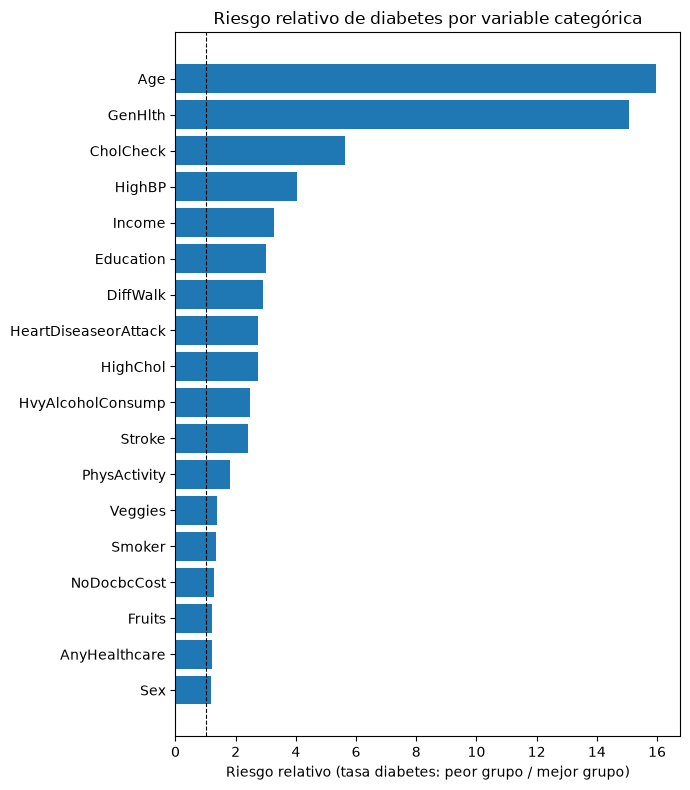

In [6]:
def columnas_categoricas(df, objetivo, umbral_valores_unicos=15):
    """Detecta columnas categoricas/ordinales: predictoras (todo menos el
    objetivo) con pocos valores unicos, para poder agruparlas y comparar
    tasas de diabetes entre grupos. BMI, MentHlth y PhysHlth quedan fuera
    porque tienen demasiados valores (84, 31 y 31) para que el agrupamiento
    sea interpretable."""
    predictoras = [c for c in df.columns if c != objetivo]
    return [c for c in predictoras if df[c].nunique() <= umbral_valores_unicos]


categoricas = columnas_categoricas(df, TARGET)
print(len(categoricas), "variables categoricas detectadas:", categoricas)

filas = []
for var in categoricas:
    tasas = df.groupby(var)[TARGET].mean()
    rr = tasas.max() / max(tasas.min(), 1e-9)
    filas.append((var, rr))

resumen = pd.DataFrame(filas, columns=["variable", "riesgo_relativo"]).sort_values("riesgo_relativo")

fig, ax = plt.subplots(figsize=(7, 8))
ax.barh(resumen["variable"], resumen["riesgo_relativo"])
ax.axvline(1.0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Riesgo relativo (tasa diabetes: peor grupo / mejor grupo)")
ax.set_title("Riesgo relativo de diabetes por variable categórica")
fig.tight_layout()
plt.show()

**Hallazgo:** `Age` y `GenHlth` muestran la mayor separación entre grupos extremos (~15-16x), seguidas de `CholCheck` y `HighBP`. Es una lectura distinta y complementaria a la correlación de Pearson: aquí se ve el efecto en los extremos de cada variable, no solo la tendencia lineal promedio.

## 5. BMI, edad y diabetes (vista multivariada)

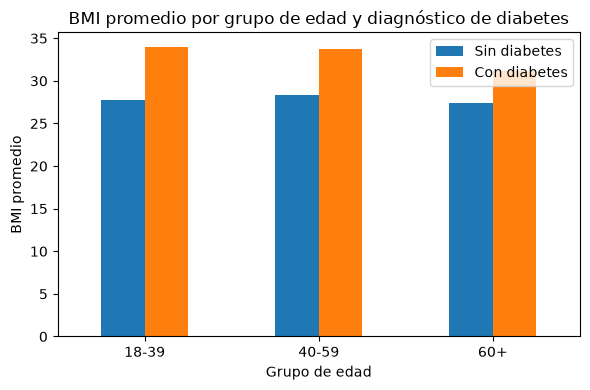

In [7]:
edad_bins = pd.cut(df["Age"], bins=[0, 4, 8, 13], labels=["18-39", "40-59", "60+"])
tabla = df.groupby([edad_bins, TARGET], observed=True)["BMI"].mean().unstack()

fig, ax = plt.subplots(figsize=(6, 4))
tabla.plot(kind="bar", ax=ax)
ax.set_ylabel("BMI promedio")
ax.set_xlabel("Grupo de edad")
ax.set_title("BMI promedio por grupo de edad y diagnóstico de diabetes")
ax.legend(["Sin diabetes", "Con diabetes"])
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
plt.show()

**Hallazgo:** en todos los grupos de edad, quienes tienen diabetes presentan un BMI promedio consistentemente más alto que quienes no la tienen, y la brecha se mantiene similar entre grupos de edad — el efecto del BMI no parece ser exclusivo de un rango etario particular.

## 6. Puntuación agregada de condiciones de riesgo

Este constituye el eje central del presente análisis. En lugar de examinar cada variable de forma aislada, elaboramos un indicador que suma las condiciones de peligro detectadas en cada individuo, y evaluamos cómo se comporta la tasa de diabetes conforme se apilan dichas condiciones.

Los criterios no se definen de manera subjetiva: se seleccionan automáticamente aquellas variables con **mayor razón de momios** (estimada en el apartado 4) y, para cada una de ellas, se clasifica a un sujeto como "expuesto" cuando su valor se sitúa en el segmento cuya incidencia de diabetes supera la media poblacional — todo inferido a partir de los propios registros, sin establecer puntos de corte arbitrarios. En el caso del `BMI`, al tratarse de una variable continua, se discretiza previamente en cuartiles derivados de su propia distribución.

In [8]:
def factores_de_alto_riesgo(df, objetivo, top_n=6):
    """Deriva automaticamente los factores de riesgo a partir del riesgo
    relativo (punto 4): toma las top_n variables con mayor riesgo relativo
    y marca a cada persona segun si su valor cae en el subgrupo cuya tasa
    de diabetes supera el promedio poblacional. BMI se incluye binandola
    en cuartiles de su propia distribucion (sin umbral fijo)."""
    df_bin = df.copy()
    df_bin["BMI (por cuartil)"] = pd.qcut(df["BMI"], 4, labels=False, duplicates="drop")

    candidatas = columnas_categoricas(df, objetivo) + ["BMI (por cuartil)"]
    tasa_global = df[objetivo].mean()

    riesgos = []
    for var in candidatas:
        tasas = df_bin.groupby(var)[objetivo].mean()
        rr = tasas.max() / max(tasas.min(), 1e-9)
        riesgos.append((var, rr, tasas))

    top = sorted(riesgos, key=lambda x: x[1], reverse=True)[:top_n]
    print("Variables seleccionadas (mayor riesgo relativo):",
          [(var, round(rr, 2)) for var, rr, _ in top])

    factores = pd.DataFrame({
        var: df_bin[var].map(tasas) > tasa_global
        for var, rr, tasas in top
    })
    return factores


factores = factores_de_alto_riesgo(df, TARGET)
puntaje = factores.sum(axis=1)

resumen_riesgo = pd.DataFrame({
    "n_personas": puntaje.value_counts().sort_index(),
    "prevalencia_diabetes": df.groupby(puntaje)[TARGET].mean(),
})
resumen_riesgo["pct_poblacion"] = resumen_riesgo["n_personas"] / len(df) * 100
resumen_riesgo

Variables seleccionadas (mayor riesgo relativo): [('Age', np.float64(15.96)), ('GenHlth', np.float64(15.06)), ('CholCheck', np.float64(5.65)), ('BMI (por cuartil)', np.float64(4.65)), ('HighBP', np.float64(4.05)), ('Income', np.float64(3.29))]


,n_personas,prevalencia_diabetes,pct_poblacion
0,1808,0.001106,0.712709
1,31610,0.008067,12.460580
2,49451,0.028432,19.493456
3,56869,0.076316,22.417613
4,54571,0.166151,21.511747
5,41617,0.300550,16.405314
6,17754,0.437535,6.998581


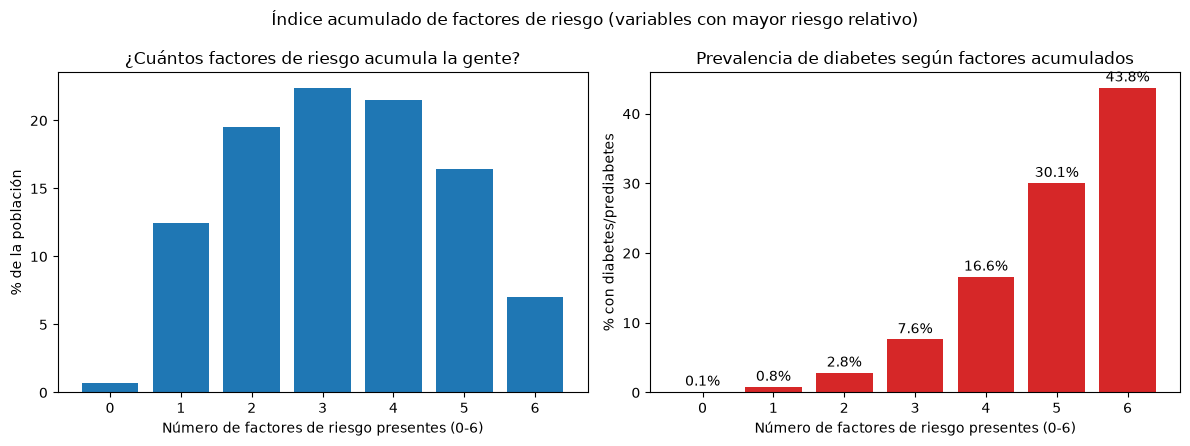

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.bar(resumen_riesgo.index.astype(str), resumen_riesgo["pct_poblacion"])
ax1.set_xlabel("Número de factores de riesgo presentes (0-6)")
ax1.set_ylabel("% de la población")
ax1.set_title("¿Cuántos factores de riesgo acumula la gente?")

bars = ax2.bar(resumen_riesgo.index.astype(str), resumen_riesgo["prevalencia_diabetes"] * 100, color="tab:red")
ax2.bar_label(bars, fmt="%.1f%%", padding=2)
ax2.set_xlabel("Número de factores de riesgo presentes (0-6)")
ax2.set_ylabel("% con diabetes/prediabetes")
ax2.set_title("Prevalencia de diabetes según factores acumulados")

fig.suptitle("Índice acumulado de factores de riesgo (variables con mayor riesgo relativo)")
fig.tight_layout()
plt.show()

**Conclusión:** la ocurrencia de diabetes crece de manera prácticamente progresiva a medida que se suman condiciones de alto riesgo (seleccionando las 6 variables con mayor odds ratio: `Age`, `GenHlth`, `CholCheck`, `BMI` por cuartil, `HighBP`, `Income`): partiendo de **0.1%** con ningún factor presente hasta alcanzar **43.8%** cuando confluyen los 6 simultáneamente. Si bien cada predictor aislado ya manifestaba vínculo con la enfermedad, examinarlos en conjunto revela un impacto aditivo sustancialmente mayor que el de cualquier variable tomada por separado. Cabe señalar que, por tratarse de un ordenamiento automático fundamentado en riesgos relativos, se colaron variables como `CholCheck` e `Income` que no constituyen factores de riesgo en sentido clínico estricto (posible distorsión: quien se practica chequeos de colesterol suele arrastrar ya alguna sospecha médica; los ingresos reflejan un condicionante social, no un biomarcador) — de cara al tablero, conviene depurar el conjunto quedándose únicamente con aquellas variables susceptibles de intervención clínica o de estilo de vida.

## 7. Conclusión

**Pregunta de negocio:** ¿se puede estimar el riesgo de diabetes sin exámenes de laboratorio, usando únicamente variables demográficas y de estilo de vida?

**Respuesta:** **sí, es viable.** Estos 6 hallazgos lo confirman:

---

**1. Datos limpios, pero con trampa**
- 0% de valores nulos, pero 9.5% de duplicados exactos.
- No son errores de captura: concentran perfiles sanos típicos.
- **Implicación:** deduplicar sin criterio sesgaría la prevalencia al alza.

**2. Outliers que engañan**
- `MentHlth` y `PhysHlth` se acumulan en 0 — la regla IQR los marca como "anómalos", pero son la norma.
- `BMI` sí tiene una cola larga real que merece revisión antes de escalar.

**3. Dos variables destacan sobre todas**
- `Age` y `GenHlth` multiplican el riesgo ~15-16× entre sus grupos extremos.
- **Implicación:** son candidatas ideales para el modelo y para el formulario del tablero.

**4. El BMI no discrimina por edad**
- El efecto del índice de masa corporal sobre el riesgo es consistente en todos los tramos etarios.
- No es un problema exclusivo de jóvenes ni de mayores.

**5. El riesgo se acumula**
- Al combinar factores de alto riesgo (incluso con una regla automática sencilla), la prevalencia salta del **0.1% al 43.8%**.
- **Implicación:** el efecto conjunto es mucho más potente que cualquier variable aislada.

**6. El desbalance persiste**
- Clase negativa (no diabéticos): **86.1%**
- Clase positiva (diabéticos): **13.9%**
- Ya identificado por el equipo, debe seguir tratándose en la modelización.

---

### Respondiendo directamente a la pregunta

> **¿Se puede estimar el riesgo de diabetes sin exámenes de laboratorio, usando variables demográficas y de estilo de vida?**

**Sí.** La evidencia más contundente es el **hallazgo 5**: el hecho de que acumular factores de riesgo eleve la prevalencia desde un 0.1% hasta un 43.8% demuestra que **combinando varias variables fáciles de recolectar se puede discriminar razonablemente bien** entre perfiles de bajo y alto riesgo, sin necesidad de pruebas clínicas.

---

**Recomendaciones operativas para las próximas semanas:**

| Acción | Prioridad |
|--------|-----------|
| No deduplicar el dataset automáticamente |  Alta |
| Mantener el tratamiento del desbalance (86.1% / 13.9%) |  Alta |
| Priorizar `Age` y `GenHlth` en el modelo y el formulario |  Media |
| Revisar la cola larga de `BMI` antes de escalar |  Media |